In [1]:
%load_ext autoreload
%autoreload 2

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils
import threepoint

In [3]:
blind = False

all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-796sims-february-Percival/des-y3-2pt-map3-all.txt', to_mcsamples=True, blind=blind)
map3_all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-796sims-february-Percival/des-y3-map3-all.txt', to_mcsamples=True, blind=blind)
twpt_all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-796sims-february-Percival/des-y3-2pt-796simcov.txt', to_mcsamples=True, blind=blind)
auto_all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-796sims-february-Percival/des-y3-2pt-map3-auto.txt', to_mcsamples=True, blind=blind)
auto_334_344_all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-796sims-february-Percival/des-y3-2pt-map3-auto-334-344.txt', to_mcsamples=True, blind=blind)

all_sims_wCDM = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-796sims-february-Percival/des-y3-2pt-map3-all-wCDM.txt', to_mcsamples=True, blind=blind)
twopoint_wCDM = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-796sims-february-Percival/des-y3-2pt-500simcov-wCDM.txt', to_mcsamples=True, blind=blind)
#map3_wCDM = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-8arcmincut-december/des-y3-map3-all-wCDM.txt', to_mcsamples=True, blind=blind)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


In [4]:
twpt_all_sims_700 = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-796sims-february-Percival/des-y3-2pt-700simcov.txt', to_mcsamples=True, blind=blind)
all_sims_700 = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-796sims-february-Percival/des-y3-2pt-map3-all-700simcov.txt', to_mcsamples=True, blind=blind)

Removed no burn in
Removed no burn in


<Figure size 600x600 with 0 Axes>

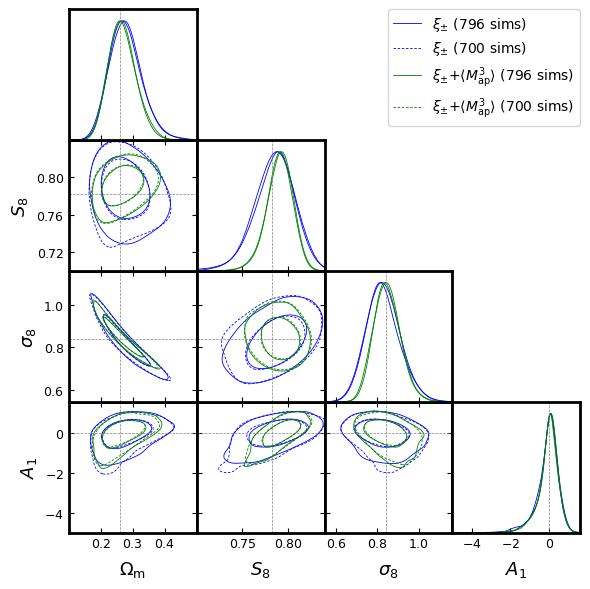

In [24]:
plt.rcParams['axes.linewidth'] = 2
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.settings.lab_fontsize = 17
g.settings.axes_fontsize = 13
g.settings.legend_fontsize = 14
g.settings.figure_legend_frame = True
g.triangle_plot([twpt_all_sims, twpt_all_sims_700, all_sims, all_sims_700], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=[r'$\xi_{\pm}$ (796 sims)', r'$\xi_{\pm}$ (700 sims)',r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$ (796 sims)', r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$ (700 sims)'], legend_loc='upper right', 
    contour_colors=['blue', 'blue', 'green', 'green'], ls=['-', '--', '-', '--'], markers={'om':0.26, 's8':0.782, 'sig8':0.84, 'a1':0})
plt.savefig("Convergence_of_map3cov_run_plot_february2025.pdf", dpi=500)
#plt.show()

<Figure size 600x600 with 0 Axes>

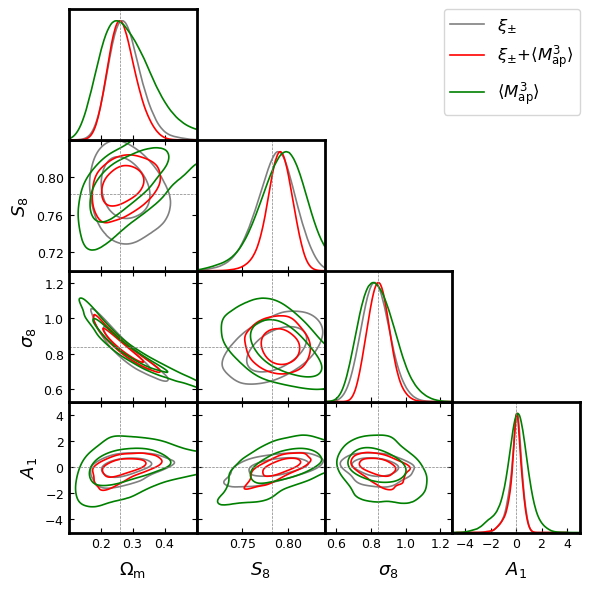

In [76]:
plt.rcParams['axes.linewidth'] = 2
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.settings.lab_fontsize = 17
g.settings.axes_fontsize = 13
g.settings.legend_fontsize = 16
g.settings.figure_legend_frame = True
g.triangle_plot([twpt_all_sims, all_sims, map3_all_sims], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=[r'$\xi_{\pm}$',r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$', r'$\langle M_{\rm ap}^3\rangle$'], legend_loc='upper right', 
    contour_colors=['gray', 'red', 'green'], markers={'om':0.26, 's8':0.782, 'sig8':0.84, 'a1':0}, contour_lws=1.2, line_args=[{'ls':'-', 'color':'gray'},
               {'lw':2, 'color':'red'}, {'ls':'-', 'color':'green'}])
#g.export("February28_map3_2pt_plot_more_params.pdf")
#plt.show()
plt.savefig("March5_map3_2pt_plot_more_params.pdf")

In [31]:
#percival fom
fom_2pt = utils.FoM_from_samples_names(twpt_all_sims, ['om', 's8'])
joint_fom = utils.FoM_from_samples_names(all_sims, ['om', 's8'])

joint_fom_auto = utils.FoM_from_samples_names(auto_all_sims, ['om', 's8'])
joint_fom_334 = utils.FoM_from_samples_names(auto_334_344_all_sims, ['om', 's8'])
print(joint_fom_auto)
print(joint_fom_auto/fom_2pt)

print(joint_fom_334)
print(joint_fom_334/fom_2pt)


print(fom_2pt, joint_fom)
print(joint_fom/fom_2pt)

1299.1660624003498
1.3972044090374927
1408.7100404126518
1.5150148518222344
929.8324955153272 1700.8141059226398
1.8291618265933187


In [48]:
def _get_HDI(x, p, alphas=[0.0, 0.68, 0.95]):
    """
    Computes the highest density intervals (HDI).
    Args:
        x: x bin
        p: probability density at x
        alphas: listy of credible probability to which the HDI are computed.
    """
    argsort = np.argsort(p)
    p_sorted = p[argsort]
    x_sorted = x[argsort]

    cumsum = np.cumsum(p_sorted)
    cumsum/= cumsum[-1]
    
    HDIS = []
    for a in alphas:
        if a == 0.0:
            idx = np.argmax(p)
            HDIS.append([x[idx], x[idx]])
        else:
            idx = np.argmax(cumsum[cumsum < 1-a])
            p_height = p_sorted[idx]
            x_range  = x[p>p_height]
            hdi_min = min(x_range)
            hdi_max = max(x_range)
            HDIS.append([hdi_min, hdi_max])
        
    return HDIS

In [50]:
d = twpt_all_sims.get1DDensity('a1')
hdis = _get_HDI(d.x, d.P, alphas=[0.68, 0.95])

sigma68 = hdis[0][1] - hdis[0][0]
sigma95 = hdis[1][1] - hdis[1][0]

print(sigma68)
print(sigma95)

0.9143231024546887
2.091174620465674


In [51]:
d = all_sims.get1DDensity('a1')
hdis = _get_HDI(d.x, d.P, alphas=[0.68, 0.95])

sigma68 = hdis[0][1] - hdis[0][0]
sigma95 = hdis[1][1] - hdis[1][0]

print(sigma68)
print(sigma95)

0.8757734894486289
2.1268784743752422


In [9]:
#Figure-of-merit improvement

fom_2pt = utils.FoM_from_samples_names(twpt_all_sims_700, ['om', 's8'])
joint_fom = utils.FoM_from_samples_names(all_sims_700, ['om', 's8'])

print(fom_2pt, joint_fom)
print(joint_fom/fom_2pt)

900.0905052052195 1690.8473003518807
1.8785303150891137


<Figure size 600x600 with 0 Axes>

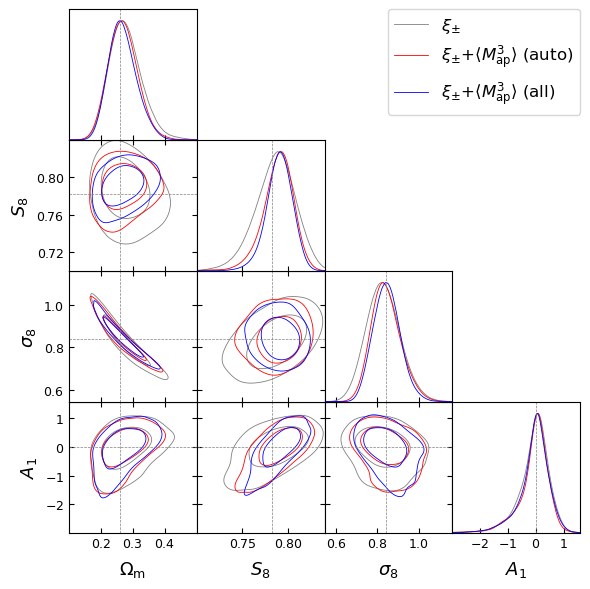

In [10]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.settings.lab_fontsize = 17
g.settings.axes_fontsize = 13
g.settings.legend_fontsize = 16
g.settings.figure_legend_frame = True
g.triangle_plot([twpt_all_sims, auto_all_sims, all_sims], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=[r'$\xi_{\pm}$',r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$ (auto)',r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$ (all)'], legend_loc='upper right', 
    contour_colors=['gray', 'red', 'blue'], markers={'om':0.26, 's8':0.782, 'sig8':0.84, 'a1':0})
plt.show()

In [ ]:
# If `.names` doesn't work, try `.list()`
parameter_names = twpt_all_sims.paramNames.list()
print(parameter_names)

<Figure size 600x600 with 0 Axes>

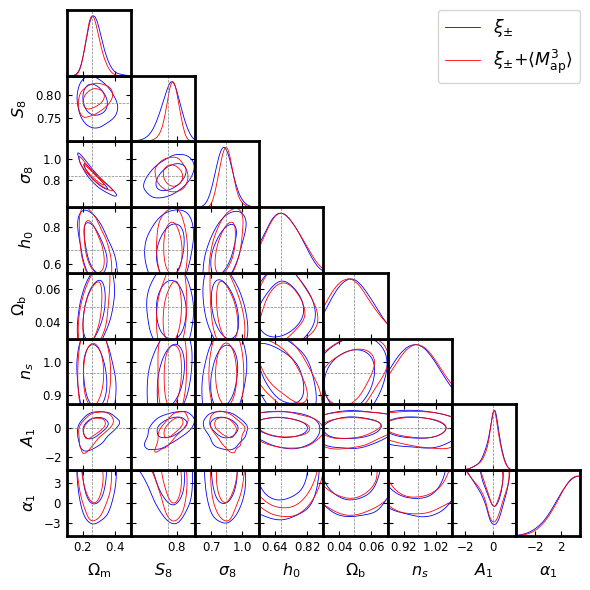

In [25]:
plt.rcParams['axes.linewidth'] = 2
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.settings.lab_fontsize = 17
g.settings.axes_fontsize = 14
g.settings.legend_fontsize = 18
g.settings.figure_legend_frame = True

# Apply the custom labels to the plotter
#g.set_labels(custom_labels)
g.triangle_plot([twpt_all_sims, all_sims], ['om', 's8', 'sig8','h0', 'ob', 'ns', 'a1', 'alpha1'], filled=False, \
    legend_labels=[r'$\xi_{\pm}$',r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$'], legend_loc='upper right', 
    contour_colors=['blue', 'red'], markers={'om':0.26, 's8':0.782, 'sig8':0.84, 'a1':0, 'ns':0.9649, 'h0':0.673, 'ob':0.0493})

plt.savefig("February28_map3_2pt_manyparams_lcdm.pdf")
#plt.show()

<Figure size 600x600 with 0 Axes>

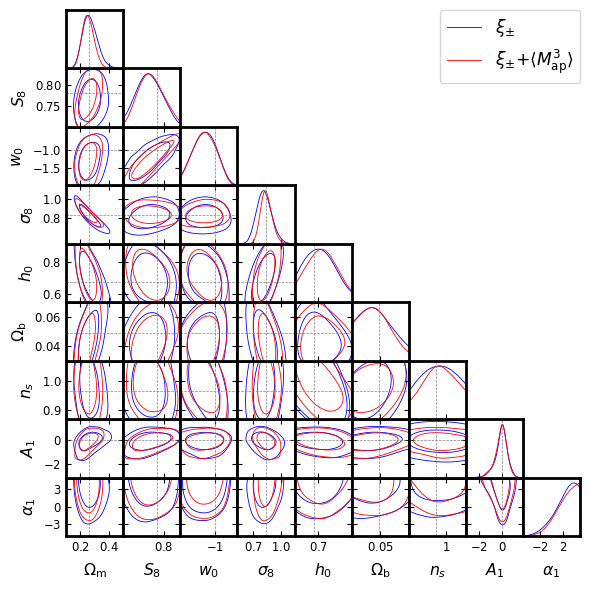

In [26]:
plt.rcParams['axes.linewidth'] = 2
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.settings.lab_fontsize = 17
g.settings.axes_fontsize = 14
g.settings.legend_fontsize = 18
g.settings.figure_legend_frame = True

# Apply the custom labels to the plotter
#g.set_labels(custom_labels)
g.triangle_plot([twopoint_wCDM, all_sims_wCDM], ['om', 's8', 'w0', 'sig8','h0', 'ob', 'ns', 'a1', 'alpha1'], filled=False, \
    legend_labels=[r'$\xi_{\pm}$',r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$'], legend_loc='upper right', 
    contour_colors=['blue', 'red'], markers={'om':0.26, 's8':0.782, 'w0':-1,'sig8':0.84, 'a1':0, 'ns':0.9649, 'h0':0.673, 'ob':0.0493})

plt.savefig("February28_map3_2pt_manyparams_wcdm.pdf")
#plt.show()

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.settings.lab_fontsize = 17
g.settings.axes_fontsize = 14
g.settings.legend_fontsize = 18
g.settings.figure_legend_frame = True

# Apply the custom labels to the plotter
#g.set_labels(custom_labels)
g.triangle_plot([twpt_all_sims, all_sims], ['om', 's8','m1', 'm2','m3','m4','dz1','dz2','dz3','dz4'], filled=False, \
    legend_labels=[r'$\xi_{\pm}$',r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$'], legend_loc='upper right', 
    contour_colors=['blue', 'red'], markers={'om':0.26, 's8':0.782,'m1':0, 'm2':0,'m3':0,'m4':0,'dz1':0,'dz2':0,'dz3':0,'dz4':0})

plt.show()

In [ ]:
import getdist
import matplotlib.pyplot as plt

# Define the dictionary for custom labels
custom_labels = {
    'om': r'$\Omega_m$',  
    's8': r'$\sigma_8$',  
    'sig8': r'$\sigma_8$',  
    'h0': r'$H_0$',  
    'cosmological_parameters--omega_b': r'$\Omega_b$', 
    'cosmological_parameters--n_s': r'$\Omega_s$',  
    'cosmological_parameters--mnu': r'$\sum m_\nu$',  
    'a1': r'$\alpha_1$',  
    'alpha1': r'$\alpha_1$',
}

# Create the plotter
g = getdist.plots.get_single_plotter(ratio=1, width_inch=6)

# Plot the triangle plot
g.triangle_plot([twpt_all_sims, all_sims], 
    ['om', 's8', 'sig8', 'h0', 'cosmological_parameters--omega_b', 'cosmological_parameters--n_s', 'cosmological_parameters--mnu', 'a1', 'alpha1'], 
    filled=False,
    legend_labels=[r'$\xi_{\pm}$', r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$'],
    legend_loc='upper right',
    contour_colors=['gray', 'red'],
    markers={'om': 0.26, 's8': 0.782, 'sig8': 0.84, 'a1': 0}
)

plt.show()

In [ ]:
def compute_s8alpha(mc_samples):
    om = mc_samples.getParams().om  # omega_m
    sig8 = mc_samples.getParams().sig8  # sigma_8
    s8alpha = sig8 * (om / 0.3) ** 0.45
    return s8alpha

# Add s8alpha to each chain
all_sims.addDerived(compute_s8alpha(all_sims), name='s8alpha', label=r'\sigma_8 (\Omega_m/0.3)^{0.45}')
map3_all_sims.addDerived(compute_s8alpha(map3_all_sims), name='s8alpha', label=r'\sigma_8 (\Omega_m/0.3)^{0.45}')
twpt_all_sims.addDerived(compute_s8alpha(twpt_all_sims), name='s8alpha', label=r'\sigma_8 (\Omega_m/0.3)^{0.45}')

In [ ]:
# Generate the plot
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot(
    [twpt_all_sims, all_sims, map3_all_sims],
    ['om', 's8alpha', 'sig8', 'a1'],  # Replace 's8' with 's8alpha'
    filled=False,
    legend_labels=['2pt', '2pt+map3', 'map3'],
    legend_loc='upper right',
    contour_colors=['gray', 'red', 'green'],
    markers={'om': 0.26, 's8alpha': 0.782 * (0.26 / 0.3) ** (-0.05)}
)
plt.show()

In [ ]:
# Function to compute s8alpha for a given alpha
def compute_s8alpha_alpha(mc_samples, alpha):
    om = mc_samples.getParams().om  # omega_m
    sig8 = mc_samples.getParams().sig8  # sigma_8
    s8alpha = sig8 * (om / 0.3) ** alpha
    return s8alpha

def test_alpha(mc_samples, fiducial_s8alpha, alpha):
    # Parameter name for the derived quantity
    param_name = 's8alpha_alpha'

    # Check if the parameter already exists and remove it
    if param_name in mc_samples.paramNames.names:
        mc_samples.removeDerived(param_name)
    
    # Compute s8alpha for the current alpha
    s8alpha = mc_samples.getParams().sig8 * (mc_samples.getParams().om / 0.3) ** alpha
    mc_samples.addDerived(s8alpha, name=param_name, label=r'\sigma_8 (\Omega_m/0.3)^{\alpha}')
    
    # Get mean and confidence limits for s8alpha_alpha
    mean_s8alpha = mc_samples.getMeans()[mc_samples.index[param_name]]  # Posterior mean
    lower_68, upper_68 = mc_samples.confidenceRegion(param_name, 0.68)  # 68% confidence interval
    
    # Compute the sigma range
    sigma_range = upper_68 - lower_68
    
    # Compute the ratio
    ratio = abs(mean_s8alpha - fiducial_s8alpha) / sigma_range
    return ratio


# Main loop to find the optimal alpha
def find_best_alpha(mc_samples, fiducial_om=0.26, fiducial_sig8=0.84, alpha_min=0.2, alpha_max=0.8, alpha_step=0.01):
    # Initialize variables
    best_alpha = None
    min_ratio = float('inf')
    fiducial_s8alpha_func = lambda alpha: fiducial_sig8 * (fiducial_om / 0.3) ** alpha

    # Loop over alpha values
    for alpha in np.arange(alpha_min, alpha_max + alpha_step, alpha_step):
        fiducial_s8alpha = fiducial_s8alpha_func(alpha)
        ratio = test_alpha(mc_samples, fiducial_s8alpha, alpha)
        if ratio < min_ratio:
            min_ratio = ratio
            best_alpha = alpha

    return best_alpha, min_ratio

# Example usage with one of your chains
best_alpha, min_ratio = find_best_alpha(all_sims)
print(f"Best alpha: {best_alpha}, Minimum ratio: {min_ratio}")


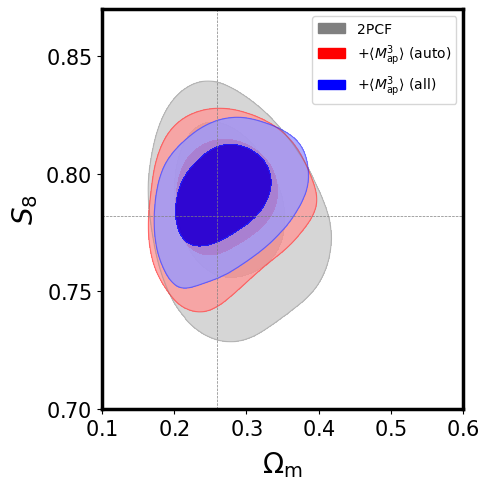

In [10]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = True
g.plot_2d([twpt_all_sims, auto_all_sims, all_sims], 'om', 's8', filled=True, 
    colors=['gray','red', 'blue'], alphas=[0.8,0.8, 0.8,0.8])
g.add_legend(['2PCF', \
    r'+$\langle M_{\rm ap}^3\rangle$ (auto)',  
    r'+$\langle M_{\rm ap}^3\rangle$ (all)'], legend_loc='upper right', fontsize=10)
g.add_x_marker(0.26)
g.add_y_marker(0.782)
g.get_axes().set_xlim(0.1, 0.6)
g.get_axes().set_ylim(0.7, 0.87)
ax = g.get_axes()  # Get the main axes object
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
#g.export("February28_map3_2pt_plot.pdf")

Text(0.59, 1.02, '$w$CDM')

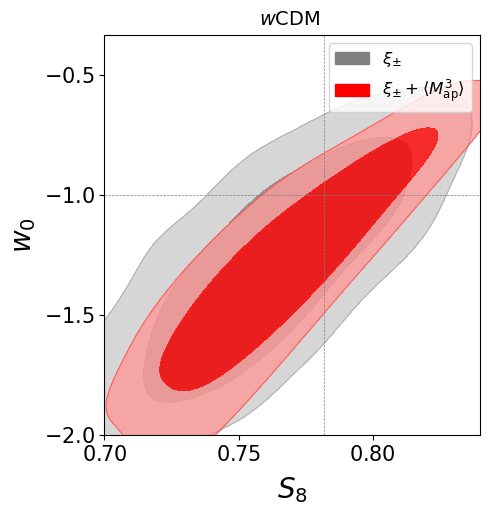

In [14]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([twopoint_wCDM, all_sims_wCDM], 's8', 'w0', filled=True, 
    colors=['gray', 'red'], alphas=[0.8, 0.8, 0.6])
g.add_legend([r'$\xi_{\pm}$', r'$\xi_{\pm} + \langle M_{\rm ap}^3\rangle$'], legend_loc='upper right')
g.add_x_marker(0.782)
g.add_y_marker(-1.0)
plt.suptitle(r'$w$CDM', y=1.02, x = 0.59, fontsize=14)
#plt.savefig('../plots/wCDM_contour2d_cosmogrid_dv_and_cov_06Dec24.pdf')

<Figure size 700x700 with 0 Axes>

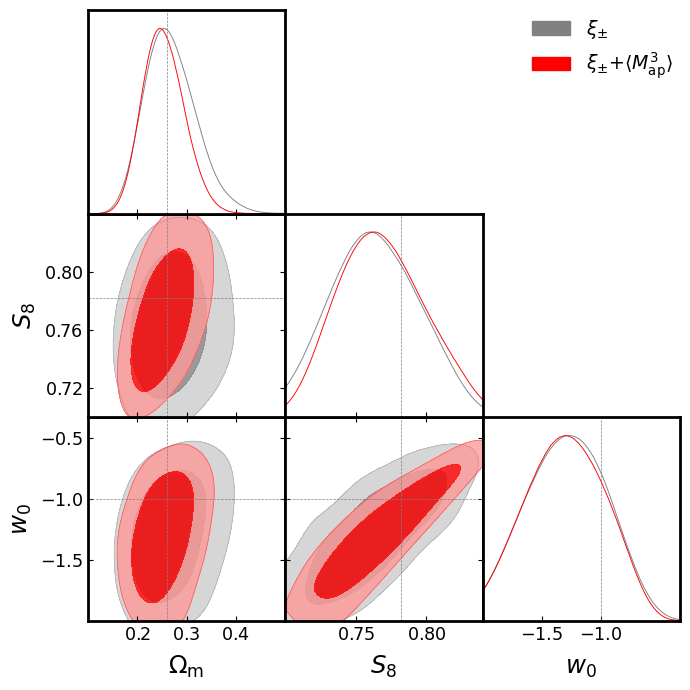

In [22]:
# Set up the plotter
plt.rcParams['axes.linewidth'] = 2
g = plots.get_single_plotter(ratio=1, width_inch=7)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.legend_fontsize = 16
g.settings.figure_legend_frame = False

# Define parameters to plot
params_to_plot = ['om', 's8', 'w0']

# Generate a corner plot
g.triangle_plot([twopoint_wCDM, all_sims_wCDM], params_to_plot, 
                filled=True, 
                colors=['gray', 'red'],
                contour_colors=['gray', 'red'],
                legend_labels=[r'$\xi_{\pm}$',r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$'],
                alphas=[0.8, 0.8], markers={'om':0.26, 's8':0.782, 'w0':-1})

# Add legend
#g.add_legend([r'$\xi_{\pm}$', r'$\xi_{\pm} + \langle M_{\rm ap}^3\rangle$'], legend_loc='upper right')

# Show the plot
#plt.show()
plt.savefig('wCDM_contour2d_moreparams_february2025.pdf')

In [16]:
fom_2pt = utils.FoM_from_samples_names(twopoint_wCDM, ['om', 's8'])
joint_fom = utils.FoM_from_samples_names(all_sims_wCDM, ['om', 's8'])

print(fom_2pt, joint_fom)
print(joint_fom/fom_2pt)

653.1504548565217 928.0895221983536
1.4209429317510436


In [17]:
fom_2pt = utils.FoM_from_samples_names(twopoint_wCDM, ['w0', 's8'])
joint_fom = utils.FoM_from_samples_names(all_sims_wCDM, ['w0', 's8'])

print(fom_2pt, joint_fom)
print(joint_fom/fom_2pt)

151.6127946347377 206.38162626726412
1.3612414886518933


In [32]:
fom_2pt = utils.FoM_from_samples_names(twopoint_wCDM, ['w0'])
joint_fom = utils.FoM_from_samples_names(all_sims_wCDM, ['w0'])

print(fom_2pt, joint_fom)
print(joint_fom/fom_2pt)

3.0684108531018817 3.098779219040829
1.009897098984723


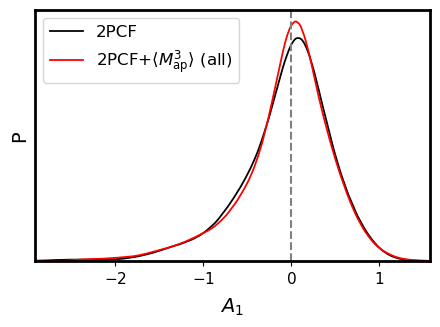

In [20]:
plt.rcParams['axes.linewidth'] = 2
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.legend_fontsize = 12
g = plots.get_single_plotter(width_inch=4.5)
g.settings.figure_legend_frame = False
g.plot_1d([twpt_all_sims, all_sims], 'a1', normalized=True)
g.add_legend(['2PCF', r'2PCF+$\langle M_{\rm ap}^3\rangle$ (all)'])
ax = g.get_axes()
ax.axvline(0, color='gray', ls='--')
g.export('post1d_AIA_2pt_map3_february2025.pdf')
#plt.show()

In [ ]:
def index_from_samples_name(samples, names):
    idx = [samples.getParamNames().list().index(name) for name in names]
    return idx

def chain_from_samples_name(samples, names):
    idx = index_from_samples_name(samples, names)
    return samples.samples[:,idx]

def find_alpha_of_s8(samples, sigma8_name='sig8', Omega_m_name='om'):
    """
    We want to find the alpha of S8 = sigma8 * Omega_m^{alpha}
    Taking the logarith of the both sides, and modifying the eq
       log(sigma8) = -alpha * log(Omega_m) + const
    We can find the alpha by linear regression of log(sigma8) and log(Omega_m)

    samples: getdist MCSamples
    """
    chain = chain_from_samples_name(samples, [Omega_m_name, sigma8_name])
    x = np.log(chain[:,0])
    y = np.log(chain[:,1])
    w = samples.weights
    c = np.cov(x, y, rowvar=False, aweights=w)
    a = -c[0,1]/c[0,0]
    return a

In [61]:
getpower = find_alpha_of_s8(twpt_all_sims)
print(getpower)

getpower_joint = find_alpha_of_s8(all_sims)
print(getpower_joint)

getpower_map3 = find_alpha_of_s8(map3_all_sims)
print(getpower_map3)

0.5268316666910555
0.46223552404753765
0.4291256775090145


In [ ]:
plt.rcParams['axes.linewidth'] = 2
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.legend_fontsize = 12
g = plots.get_single_plotter(width_inch=4.5)
g.settings.figure_legend_frame = False
g.plot_1d([twpt_all_sims, all_sims, auto_all_sims, auto_334_344_all_sims], 'a1', normalized=True)
g.add_legend(['2PCF', r'2PCF+$\langle M_{\rm ap}^3\rangle$ (all)',r'2PCF+$\langle M_{\rm ap}^3\rangle$ (auto)', r'2PCF+$\langle M_{\rm ap}^3\rangle$ (auto+334+344)'])
ax = g.get_axes()
ax.axvline(0, color='gray', ls='--')
plt.show()

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([twpt_all_sims, twpt_all_sims_400, all_sims, all_sims_400], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=[r'$\xi_{\pm}$ (500 sims)', r'$\xi_{\pm}$ (400 sims)',r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$ (500 sims)', r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$ (400 sims)'], legend_loc='upper right', 
    contour_colors=['blue', 'blue', 'green', 'green'], ls=['-', '--', '-', '--'], markers={'om':0.26, 's8':0.782})
plt.show()

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([twopt_meas, all_sims, map3_all_sims], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt', '2pt+map3', 'map3'], legend_loc='upper right', 
    contour_colors=['gray', 'red', 'green'], markers={'om':0.26, 's8':0.782})
#plt.savefig("Oct30_sim_analysis_cosmogridcutcov.pdf")
plt.show()

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([twopt_meas, twpt_all_sims, all_sims], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt(meas)', '2pt(theo)', '2pt+map3'], legend_loc='upper right', 
    contour_colors=['gray', 'blue', 'red'])
#plt.savefig("Oct30_sim_analysis_cosmogridcutcov.pdf")
plt.show()

In [ ]:
#load covariances w/ 500 sims and 400 sims
from astropy.io import fits

cov500 = fits.open("../data/covariance/xip_xim_map3_covariance_8ARCMINCUT_31Oct24.fits")
cov400 = fits.open("../data/covariance/xip_xim_map3_covariance_8ARCMINCUT_400SIMCOV_9Nov.fits")

mycov500 = cov500[1].data[400:,:][:,400:]
mycov400 = cov400[1].data[400:,:][:,400:]

corr400 = mycov400 / np.sqrt(np.outer(np.diag(mycov400), np.diag(mycov400)))
corr500 = mycov500 / np.sqrt(np.outer(np.diag(mycov500), np.diag(mycov500)))

# Compute the Frobenius norm difference
frobenius_diff = np.linalg.norm(mycov400 - mycov500, 'fro')
print(frobenius_diff)

# Create a combined matrix with upper triangle from corr500 and lower triangle from corr400
combined_corr = np.tril(corr500) + np.triu(corr400, k=1)
#combined_corr = np.tril(corr500)
# Plot the combined correlation matrix
fig, ax = plt.subplots(figsize=(8, 8))
#cax = ax.matshow(combined_corr, cmap='coolwarm')

cax = ax.imshow(combined_corr, cmap='coolwarm', origin='lower')

for v in range(20):
    ax.axhline(v*4, color='k', lw=0.1)
    ax.axvline(v*4, color='k', lw=0.1)
# label
labels = []
for i in range(4):
    for j in range(i, 4):
        for k in range(j, 4):
            labels.append(f'{i+1}{j+1}{k+1}')
ax.set_xticks(4*np.arange(20)+2, labels, rotation=90)
ax.set_yticks(4*np.arange(20)+2, labels)

plt.colorbar(cax)

# Add titles and Frobenius norm difference annotation
#ax.set_title("Combined Correlation Matrix\nUpper: mycov500, Lower: mycov400", pad=20)
plt.show()
#plt.savefig("../plots/combined_corr_upper500sims_lower400sims.pdf", dpi=500)

In [ ]:
#Compute the signal-to-noise: total and per bin

def total_signal_to_noise(data_vector, covariance_matrix):
    """Computes the total signal-to-noise ratio for the full data vector and covariance matrix."""
    inv_cov = np.linalg.inv(covariance_matrix)
    sn_total_squared = data_vector.T @ inv_cov @ data_vector
    return np.sqrt(sn_total_squared)

def sectionwise_signal_to_noise(data_vector, covariance_matrix, section_size=4):
    """Computes the signal-to-noise ratio for each section of the data vector and covariance matrix."""
    num_sections = len(data_vector) // section_size
    sn_sections = []
    
    for i in range(num_sections):
        start_idx = i * section_size
        end_idx = start_idx + section_size
        
        data_section = data_vector[start_idx:end_idx]
        cov_section = covariance_matrix[start_idx:end_idx, start_idx:end_idx]
        
        inv_cov_section = np.linalg.inv(cov_section)
        sn_section_squared = data_section.T @ inv_cov_section @ data_section
        sn_sections.append(np.sqrt(sn_section_squared))
    
    return sn_sections

In [ ]:
def modified_signal_to_noise(data_vector, covariance_matrix):
    """Computes the signal-to-noise ratio after removing the first element of each 4-element sequence."""
    # Indices to keep (i.e., remove 0, 4, 8, 12, ..., 76)
    indices_to_keep = [i for i in range(len(data_vector)) if i % 4 != 0]
    
    # Reduced data vector and covariance matrix
    reduced_data_vector = data_vector[indices_to_keep]
    reduced_covariance_matrix = covariance_matrix[np.ix_(indices_to_keep, indices_to_keep)]
    
    # Compute S/N
    inv_reduced_cov = np.linalg.inv(reduced_covariance_matrix)
    sn_squared = reduced_data_vector.T @ inv_reduced_cov @ reduced_data_vector
    return np.sqrt(sn_squared)

def smallscale_signal_to_noise(data_vector, covariance_matrix):
    
    indices_to_keep = [i for i in range(len(data_vector)) if i % 4 == 0]
    reduced_data_vector = data_vector[indices_to_keep]
    reduced_covariance_matrix = covariance_matrix[np.ix_(indices_to_keep, indices_to_keep)]
    inv_reduced_cov = np.linalg.inv(reduced_covariance_matrix)
    sn_squared = reduced_data_vector.T @ inv_reduced_cov @ reduced_data_vector
    return np.sqrt(sn_squared)

In [ ]:
from astropy.io import fits

my_cov_data_file = fits.open('../data/dv/sim_map3-desy3c_cosmogridcutcov.fits')
my_cov_data_file_2 = fits.open('../data/dv/meas_map3-ave-cosmogrid_weighted.fits')
my_sim_data_file = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-nocut-b.fits')
my_avg_data_file = fits.open('../data/dv/meas_map3-ave-cosmogrid_weighted.fits') #avg data with no cut
my_sim_data_file_2 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-5arcmincut.fits') #with 5arcmin cut
my_sim_data_file_6arcmin = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-6arcmincut.fits') #with 6arcmin cut
my_sim_data_file_8arcmin = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-8arcmincut.fits') #with 8arcmin cut
my_sim_data_file_3 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-11arcmincut.fits') #with 11arcmin cut

my_sim_data_file_tent = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-1Nov24-6arcmincut-tentativemap3v.fits')
my_sim_data_file_tent2 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-2Nov24-8arcmincut-tentativemap3v2.fits')
my_sim_data_file_tent3 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-2Nov24-8arcmincut-tentativemap3v3.fits')

my_sim_data_file_8arcmin_cmg = fits.open('../data/dv/sim_map3-cosmoCosmogrid-6Nov24-8arcmincut-WITH_COV.fits')

#my_sim_data = my_sim_data_file[1].data #sim data with no cut
#my_sim_data = my_avg_data_file[1].data #avg data with no cut
#my_sim_data = my_sim_data_file_2[1].data #sim data 5arcmin cut
#my_sim_data = my_sim_data_file_6arcmin[1].data #sim data 6arcmin cut
#my_sim_data = my_sim_data_file_8arcmin[1].data #sim data 8arcmin cut
#my_sim_data = my_sim_data_file_3[1].data #sim data 11arcmin cut
#my_sim_data = np.load("../data/dv/map3_average_5arcmincut_maxn100.npy") #avg data with 5arcmin cut

#my_sim_data = my_sim_data_file_tent[1].data #sim data 6arcmin cut and 9,17,28,43 map3 vals
#my_sim_data = my_sim_data_file_tent2[1].data #sim data 8arcmin cut and 8,16,28,45 map3 vals
#my_sim_data = my_sim_data_file_tent3[1].data #sim data 8arcmin cut and 6,12,24,40 map3 vals

my_sim_data = my_sim_data_file_8arcmin_cmg[1].data #sim data 8arcmin cut at cosmogrid cosmology

#my_cut_cov = my_cov_data_file[2].data #cov with 11arcmin scalecut
my_cut_cov = np.load("../data/covariance/map3_covariance_8arcmincut_maxn100.npy") #cov with 8 arcmin scalecut
#my_cut_cov = np.load("../data/covariance/map3_covariance_6arcmincut_maxn100.npy") #cov with 6 arcmin scalecut
#my_cut_cov = np.load("../data/covariance/map3_covariance_5arcmincut_maxn100.npy") #cov with 5arcmin scalecut
#my_cut_cov = my_cov_data_file_2[2].data #cov with no scalecut

#my_cut_cov = np.load("../data/covariance/map3_covariance_6arcmincut_tentativemap3v.npy") #cov with 6arcmin cut and 9,17,28,43 map3 vals
#my_cut_cov = np.load("../data/covariance/map3_covariance_8arcmincut_tentativemap3v2.npy") #cov with 8arcmin cut and 8,16,28,45 map3 vals
#my_cut_cov = np.load("../data/covariance/map3_covariance_8arcmincut_tentativemap3v3.npy") #cov with 8arcmin cut and 6,12,24,40 map3 vals

data_tot = np.zeros(80)
for i in range(80):
    data_tot[i] = my_sim_data[i][6]
#data_tot = my_sim_data
cov_tot = np.array(my_cut_cov)

In [ ]:
print(my_sim_data)

In [ ]:
print(total_signal_to_noise(data_tot,cov_tot))

In [ ]:
print(modified_signal_to_noise(data_tot,cov_tot))

In [ ]:
print(smallscale_signal_to_noise(data_tot,cov_tot))

In [ ]:
print(sectionwise_signal_to_noise(data_tot,cov_tot))

In [ ]:
#Compare plots of sim data with different cuts
def plot_data_vector_sections(data_vectors, covariance_matrices, section_index):
    """Plots the specified section of each data vector with error bars, labeled by redshift bin combination.
    
    Args:
        data_vectors (list of np.ndarray): List of data vectors.
        covariance_matrices (list of np.ndarray): List of covariance matrices.
        section_index (int): Index specifying which section (0 to 19) to plot.
    """
    # Validate inputs
    assert 0 <= section_index < 20, "section_index must be between 0 and 19."
    assert len(data_vectors) == len(covariance_matrices), "Data vectors and covariance matrices must have the same length."

    # Define the redshift bin combinations
    redshift_bins = [
        "111", "112", "113", "114", "122", "123", "124", "133", "134", "144",
        "222", "223", "224", "233", "234", "244", "333", "334", "344", "444"
    ]
    
    # Define the x-axis values and small shifts for visualization
    x_nominal = np.array([7, 14, 25, 40])  # Nominal x-axis values in arcminutes
    shift_values = np.linspace(-0.8, 0.8, len(data_vectors))  # Small shifts for each line

    # Plotting each data vector section with error bars
    plt.figure(figsize=(10, 6))
    
    for i, (data_vector, covariance_matrix) in enumerate(zip(data_vectors, covariance_matrices)):
        # Extract the specified section of the data vector and covariance matrix
        start_idx = section_index * 4
        end_idx = start_idx + 4
        data_section = data_vector[start_idx:end_idx]
        cov_section = covariance_matrix[start_idx:end_idx, start_idx:end_idx]

        # Compute errors as the square root of the diagonal of the covariance matrix section
        errors = np.sqrt(np.diag(cov_section))

        # Apply a small shift to the x-axis values
        x_shifted = x_nominal + shift_values[i]

        # Plot with error bars
        plt.errorbar(x_shifted, x_nominal**4*data_section, yerr=x_nominal**4*errors, fmt='o', label=f'Data Vector {i+1}')
    
    # Labeling
    #plt.yscale("log")
    plt.xlabel(r'$\theta$ (arcminutes)')
    plt.ylabel(r'$\theta^4 \times M_{ap}^3(\theta)$')
    plt.title(f'Redshift Bin Combination {redshift_bins[section_index]} of Data Vectors')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
my_cov_data_file = fits.open('../data/dv/sim_map3-desy3c_cosmogridcutcov.fits')
my_cov_data_file_2 = fits.open('../data/dv/meas_map3-ave-cosmogrid_weighted.fits')
my_sim_data_file = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-nocut-b.fits')
my_avg_data_file = fits.open('../data/dv/meas_map3-ave-cosmogrid_weighted.fits') #avg data with no cut
my_sim_data_file_2 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-5arcmincut.fits') #with 5arcmin cut
my_sim_data_file_6arcmin = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-6arcmincut.fits') #with 6arcmin cut
my_sim_data_file_8arcmin = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-8arcmincut.fits') #with 8arcmin cut
my_sim_data_file_3 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-11arcmincut.fits') #with 11arcmin cut

my_sim_data0 = my_sim_data_file[1].data #sim data with no cut
my_sim_data5 = my_sim_data_file_2[1].data #sim data 5arcmin cut
my_sim_data6 = my_sim_data_file_6arcmin[1].data #sim data 6arcmin cut
my_sim_data8 = my_sim_data_file_8arcmin[1].data #sim data 8arcmin cut
my_sim_data11 = my_sim_data_file_3[1].data #sim data 11arcmin cut
my_sim_data_AVG = my_avg_data_file[1].data #avg data

my_cut_cov11 = my_cov_data_file[2].data #cov with 11arcmin scalecut
my_cut_cov8 = np.load("../data/covariance/map3_covariance_8arcmincut_maxn100.npy") #cov with 8 arcmin scalecut
my_cut_cov6 = np.load("../data/covariance/map3_covariance_6arcmincut_maxn100.npy") #cov with 6 arcmin scalecut
my_cut_cov5 = np.load("../data/covariance/map3_covariance_5arcmincut_maxn100.npy") #cov with 5arcmin scalecut
my_cut_cov0 = my_cov_data_file_2[2].data #cov with no scalecut

data_tot0 = np.zeros(80)
data_tot5 = np.zeros(80)
data_tot6 = np.zeros(80)
data_tot8 = np.zeros(80)
data_tot11 = np.zeros(80)
data_tot_AVG = np.zeros(80)

for i in range(80):
    data_tot0[i] = my_sim_data0[i][6]
    data_tot5[i] = -my_sim_data5[i][6]
    data_tot6[i] = -my_sim_data6[i][6]
    data_tot8[i] = -my_sim_data8[i][6]
    data_tot11[i] = -my_sim_data11[i][6]
    data_tot_AVG[i] = my_sim_data_AVG[i][6]

cov_tot0 = np.array(my_cut_cov0)
cov_tot5 = np.array(my_cut_cov5)
cov_tot6 = np.array(my_cut_cov6)
cov_tot8 = np.array(my_cut_cov8)
cov_tot11 = np.array(my_cut_cov11)

data_arr = [data_tot0, data_tot5, data_tot6, data_tot8, data_tot11]
cov_arr = [cov_tot0, cov_tot5, cov_tot6, cov_tot8, cov_tot11]
plot_data_vector_sections(data_arr, cov_arr, 19)

In [ ]:
data_arr = [data_tot0, data_tot_AVG]
cov_arr = [cov_tot0, cov_tot0]
plot_data_vector_sections(data_arr, cov_arr, 15)

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([twopoint_wCDM, map3_wCDM, all_sims_wCDM], ['om', 's8', 'w0'], filled=False, \
    legend_labels=['2pt only', 'map3 only', '2pt+map3'], legend_loc='upper right', 
    contour_colors=['green', 'red', 'blue'])
plt.show()

In [ ]:
fom_2pt = utils.FoM_from_samples_names(twpt_all_sims, ['om', 's8'])
auto_fom = utils.FoM_from_samples_names(auto_all_sims, ['om', 's8'])
auto_334_344_fom = utils.FoM_from_samples_names(auto_334_344_all_sims, ['om', 's8'])
joint_fom = utils.FoM_from_samples_names(all_sims_700, ['om', 's8'])

#fom_2pt_400 = utils.FoM_from_samples_names(twpt_all_sims_400, ['om', 's8'])
#joint_fom_400 = utils.FoM_from_samples_names(all_sims_400, ['om', 's8'])

print(fom_2pt, joint_fom)
print(joint_fom/fom_2pt)

print(fom_2pt, auto_fom)
print(auto_fom/fom_2pt)

print(fom_2pt, auto_334_344_fom)
print(auto_334_344_fom/fom_2pt)

#print(fom_2pt_400, joint_fom_400)
#print(joint_fom_400/fom_2pt_400)

In [ ]:
def covmatparams(mcchain, index=0.5):#manual check of the det(cov)
    # Assuming twpt_all_sims contains samples and weights is the corresponding weight array
    omega_m_samples = mcchain['om']
    sigma_8_samples = mcchain['sig8']*(mcchain['om']/0.3)**index
    weights = mcchain.weights

    # Step 1: Calculate the weighted mean for each parameter
    mean_omega_m = np.sum(weights * omega_m_samples) / np.sum(weights)
    mean_sigma_8 = np.sum(weights * sigma_8_samples) / np.sum(weights)

    # Step 2: Calculate deviations from the weighted mean
    delta_omega_m = omega_m_samples - mean_omega_m
    delta_sigma_8 = sigma_8_samples - mean_sigma_8

    # Step 3: Calculate the weighted covariance elements
    cov_omega_m_omega_m = np.sum(weights * delta_omega_m * delta_omega_m) / np.sum(weights)
    cov_sigma_8_sigma_8 = np.sum(weights * delta_sigma_8 * delta_sigma_8) / np.sum(weights)
    cov_omega_m_sigma_8 = np.sum(weights * delta_omega_m * delta_sigma_8) / np.sum(weights)

    # Step 4: Construct the 2x2 weighted covariance matrix
    weighted_cov_matrix = np.array([[cov_omega_m_omega_m, cov_omega_m_sigma_8],
                                [cov_omega_m_sigma_8, cov_sigma_8_sigma_8]])

    #print("Weighted 2x2 Covariance Matrix:")
    #print(weighted_cov_matrix)
    #print(np.linalg.det(weighted_cov_matrix))
    #print(1/(np.sqrt(np.linalg.det(weighted_cov_matrix))))
    return(1/(np.sqrt(np.linalg.det(weighted_cov_matrix))))

In [ ]:
def covmap_improv(mcchain1, mcchain2, index=0.5):
    fom1 = covmatparams(mcchain1, index)
    fom2 = covmatparams(mcchain2, index)
    return(fom2/fom1)

In [ ]:
covmatparams(twpt_all_sims)
covmatparams(twpt_all_sims_400)
covmatparams(all_sims)
covmatparams(all_sims_400)

In [ ]:
fom_2pt = utils.FoM_from_samples_names(twpt_all_sims, ['s8'])
joint_fom = utils.FoM_from_samples_names(all_sims, ['s8'])

fom_2pt_400 = utils.FoM_from_samples_names(twpt_all_sims_400, ['s8'])
joint_fom_400 = utils.FoM_from_samples_names(all_sims_400, ['s8'])

print(fom_2pt)
print(joint_fom)
print(fom_2pt_400)
print(joint_fom_400)

In [46]:
# Get parameter names
param_names_all_sims = all_sims.getParamNames().names  # Correctly get the list of parameter names as strings

# Marginalized means
mean_all_sims = all_sims.getMeans()

# Marginalized standard deviations (uncertainties)
sigma_all_sims = [all_sims.std([param]) for param in param_names_all_sims]

# Repeat for the other chains
param_names_map3_all_sims = map3_all_sims.getParamNames().names
mean_map3_all_sims = map3_all_sims.getMeans()
sigma_map3_all_sims = [map3_all_sims.std([param]) for param in param_names_map3_all_sims]

param_names_twpt_all_sims = twpt_all_sims.getParamNames().names
mean_twpt_all_sims = twpt_all_sims.getMeans()
sigma_twpt_all_sims = [twpt_all_sims.std([param]) for param in param_names_twpt_all_sims]

# Print the marginalized means and uncertainties
print("Marginalized Means and Uncertainties for all_sims:")
for param, mean, sigma in zip(param_names_all_sims, mean_all_sims, sigma_all_sims):
    print(f"{param}: {float(mean):.4f} ± {float(sigma):.4f}")

print("\nMarginalized Means and Uncertainties for map3_all_sims:")
for param, mean, sigma in zip(param_names_map3_all_sims, mean_map3_all_sims, sigma_map3_all_sims):
    print(f"{param}: {float(mean):.4f} ± {float(sigma):.4f}")

print("\nMarginalized Means and Uncertainties for twpt_all_sims:")
for param, mean, sigma in zip(param_names_twpt_all_sims, mean_twpt_all_sims, sigma_twpt_all_sims):
    print(f"{param}: {float(mean):.4f} ± {float(sigma):.4f}")

Marginalized Means and Uncertainties for all_sims:
om	\Omega_{\rm m}: 0.2675 ± 0.0434
h0	h_0: 0.6981 ± 0.0818
ob	\Omega_{\rm b}: 0.0478 ± 0.0099
ns	n_s: 0.9660 ± 0.0504
s8	S_8: 0.7905 ± 0.0143
mnu	\Sigma m_{\nu}: 0.3089 ± 0.1425
m1	m_1: -0.0063 ± 0.0085
m2	m_2: -0.0203 ± 0.0072
m3	m_3: -0.0243 ± 0.0068
m4	m_4: -0.0362 ± 0.0066
dz1	\Delta z_1: -0.0042 ± 0.0130
dz2	\Delta z_2: -0.0015 ± 0.0104
dz3	\Delta z_3: -0.0004 ± 0.0090
dz4	\Delta z_4: 0.0039 ± 0.0129
a1	A_1: -0.0526 ± 0.5252
alpha1	\alpha_1: 2.4471 ± 1.8358
sig8	\sigma_8: 0.8449 ± 0.0651
COSMOLOGICAL_PARAMETERS--SIGMA_12	COSMOLOGICAL_PARAMETERS--SIGMA_12: 0.8234 ± 0.0654
2pt_chi2	\chi^2_{\rm 2pt}: 4.3702 ± 2.8102
map3_chi2	\chi^2_{\rm map3}: 1.0423 ± 0.9667
prior	prior: 30.6812 ± 1.4502
like	like: -2.4003 ± 1.3557
post	post: 28.2809 ± 2.0337
weight	weight: 0.0004 ± 0.0001

Marginalized Means and Uncertainties for map3_all_sims:
om	\Omega_{\rm m}: 0.2820 ± 0.0780
h0	h_0: 0.7060 ± 0.0915
ob	\Omega_{\rm b}: 0.0480 ± 0.0103
ns	n_s: 0.

In [ ]:
# Define the parameters you're interested in
#params = ['om', 's8', 'h0', 'cosmological_parameters--n_s', 'cosmological_parameters--omega_b', 'cosmological_parameters--mnu', 'a1']
params = ['a1']

for param in params:
    # Get quantiles for the parameter (68% confidence interval)
    #v1 = all_sims_wCDM.confidence(param, 0.16, upper=False)
    #v2 = all_sims_wCDM.confidence(param, 0.16, upper=True)
    #v1 = twopoint_wCDM.confidence(param, 0.16, upper=False)
    #v2 = twopoint_wCDM.confidence(param, 0.16, upper=True)
    #v1 = all_sims.confidence(param, 0.16, upper=False)
    #v2 = all_sims.confidence(param, 0.16, upper=True)
    #v1 = twpt_all_sims.confidence(param, 0.16, upper=False)
    #v2 = twpt_all_sims.confidence(param, 0.16, upper=True)
    v1 = auto_334_344_all_sims.confidence(param, 0.16, upper=False)
    v2 = auto_334_344_all_sims.confidence(param, 0.16, upper=True)

    
    # Compute the peak (mean)
    peak = auto_334_344_all_sims.getMeans()
    
    print(f"Parameter: {param}")
    print(f"Peak: {peak}")
    print(f"1-sigma Lower: {v1}")
    print(f"1-sigma Upper: {v2}")

In [52]:
# Define the parameters you're interested in
#params = ['om', 's8', 'h0', 'cosmological_parameters--n_s', 'cosmological_parameters--omega_b', 'cosmological_parameters--mnu', 'a1']
#params = ['om', 's8']
params = ['a1']

for param in params:
    # Get quantiles for the parameter (68% confidence interval)
    #v1 = all_sims_wCDM.confidence(param, 0.16, upper=False)
    #v2 = all_sims_wCDM.confidence(param, 0.16, upper=True)
    #v1 = twopoint_wCDM.confidence(param, 0.16, upper=False)
    #v2 = twopoint_wCDM.confidence(param, 0.16, upper=True)
    v1 = twpt_all_sims.confidence(param, 0.16, upper=False)
    v2 = twpt_all_sims.confidence(param, 0.16, upper=True)
    #v1 = all_sims.confidence(param, 0.16, upper=False)
    #v2 = all_sims.confidence(param, 0.16, upper=True)
    
    #v1 = s_baryon.confidence(param, 0.16, upper=False)
    #v2 = s_baryon.confidence(param, 0.16, upper=True)
    #v1 = map3_all_sims.confidence(param, 0.16, upper=False)
    #v2 = map3_all_sims.confidence(param, 0.16, upper=True)

    
    # Compute the peak (mean)
    peak = twpt_all_sims.getMeans()
    
    print(f"Parameter: {param}")
    print(f"Peak: {peak}")
    print(f"1-sigma Lower: {v1}")
    print(f"1-sigma Upper: {v2}")
    
#a1 for 2pt: -5.12287129e-02. Lower:-0.5274720493015614. Upper 0.41715045655719596
#a1 for joint: -5.25519042e-02. Lower: -0.502986296705835. Upper 0.4145284466538621

Parameter: a1
Peak: [ 2.77165790e-01  6.93582256e-01  4.86160696e-02  9.62735944e-01
  7.85852041e-01  3.18451293e-01 -7.05709546e-03 -1.98894484e-02
 -2.45245941e-02 -3.65313653e-02 -2.99849029e-03 -1.77180012e-03
 -9.81156093e-05  4.06239880e-03 -5.12287129e-02  2.31794747e+00
  8.28039043e-01  8.09281682e-01  6.11655069e+00  3.06585089e+01
 -2.09114241e+00  2.85673665e+01  4.03157102e-04]
1-sigma Lower: -0.5274720493015614
1-sigma Upper: 0.41715045655719596


In [ ]:
# Define the parameters you're interested in
#params = ['om', 's8', 'h0', 'cosmological_parameters--n_s', 'cosmological_parameters--omega_b', 'cosmological_parameters--mnu', 'a1']
params = ['a1']

for param in params:
    # Get quantiles for the parameter (68% confidence interval)
    #v1 = all_sims_wCDM.confidence(param, 0.16, upper=False)
    #v2 = all_sims_wCDM.confidence(param, 0.16, upper=True)
    #v1 = twopoint_wCDM.confidence(param, 0.16, upper=False)
    #v2 = twopoint_wCDM.confidence(param, 0.16, upper=True)
    #v1 = all_sims.confidence(param, 0.16, upper=False)
    #v2 = all_sims.confidence(param, 0.16, upper=True)
    v1 = all_sims_percival.confidence(param, 0.16, upper=False)
    v2 = all_sims_percival.confidence(param, 0.16, upper=True)

    
    # Compute the peak (mean)
    peak = all_sims_percival.getMeans()
    
    print(f"Parameter: {param}")
    print(f"Peak: {peak}")
    print(f"1-sigma Lower: {v1}")
    print(f"1-sigma Upper: {v2}")

In [39]:
#BARYON CHAINS
s_2pt_baryon = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-796sims-february-Percival/des-y3-2pt-baryon.txt', to_mcsamples=True, blind=False)
s_baryon = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-796sims-february-Percival/des-y3-2pt-map3-all-baryon.txt', to_mcsamples=True, blind=False)
s_map3_baryon = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-796sims-february-Percival/des-y3-map3-all-baryon.txt', to_mcsamples=True, blind=False)

Removed no burn in
Removed no burn in
Removed no burn in


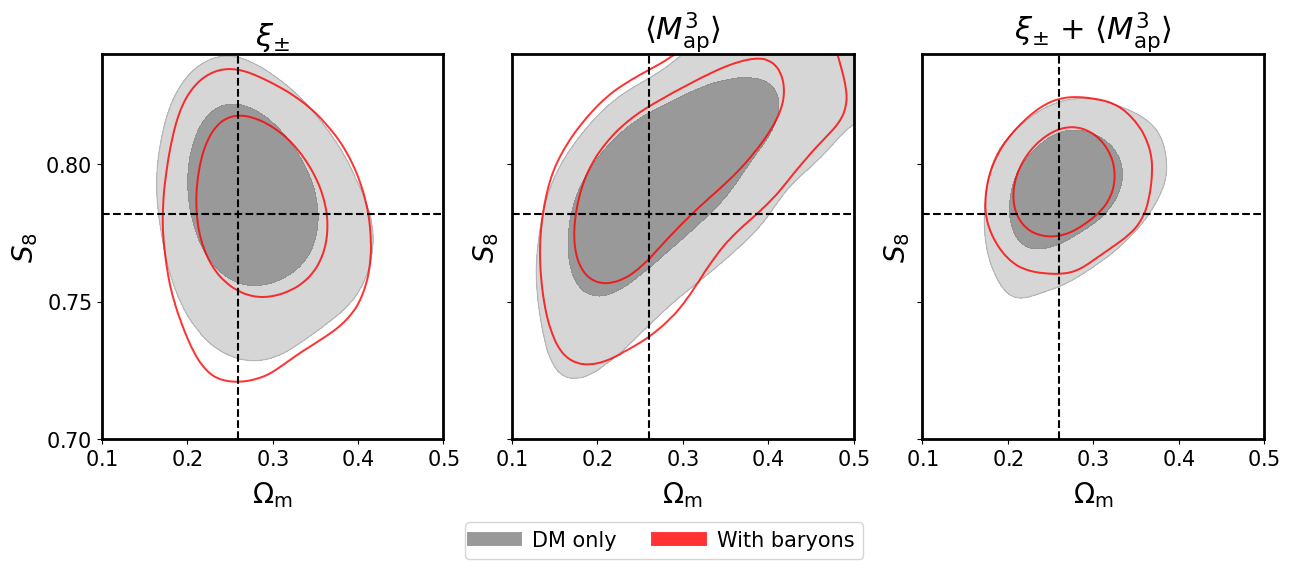

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

In [29]:
from getdist import plots
import matplotlib.pyplot as plt

# Create a 1x3 subplot layout
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)  # Share y-axis for better comparison

# Define handles and labels for the legend
legend_handles = [
    plt.Line2D([0], [0], color='gray', alpha=0.8, lw=10),  # DM only
    plt.Line2D([0], [0], color='red', alpha=0.8, lw=10)    # With baryons
]
legend_labels = ['DM only', 'With baryons']

# Panel 1: s_joint and s_baryon
g1 = plots.get_single_plotter(ratio=1, width_inch=5)
g1.settings.lab_fontsize = 20
g1.settings.axes_fontsize = 15
g1.settings.figure_legend_frame = False
g1.plot_2d([twpt_all_sims, s_2pt_baryon], 'om', 's8', filled=[True, False],
           colors=['gray', 'red'], alphas=[0.8, 0.8], ax=axes[0], new_plot=False)
axes[0].set_title(r'$\xi_{\pm}$', fontsize=22)  # Increased font size
axes[0].axvline(0.26, color='black', linestyle='--')
axes[0].axhline(0.782, color='black', linestyle='--')

# Panel 2: s_2pt and s_2pt_baryon
g2 = plots.get_single_plotter(ratio=1, width_inch=5)
g2.settings.lab_fontsize = 20
g2.settings.axes_fontsize = 15
g2.settings.figure_legend_frame = False
g2.plot_2d([map3_all_sims, s_map3_baryon], 'om', 's8', filled=[True, False],
           colors=['gray', 'red'], alphas=[0.8, 0.8], ax=axes[1], new_plot=False)
axes[1].set_title(r'$\langle M_{\rm ap}^3\rangle$', fontsize=22)  # Increased font size
axes[1].axvline(0.26, color='black', linestyle='--')
axes[1].axhline(0.782, color='black', linestyle='--')

# Panel 3: s_map3 and s_map3_baryon
g3 = plots.get_single_plotter(ratio=1, width_inch=5)
g3.settings.lab_fontsize = 20
g3.settings.axes_fontsize = 15
g3.settings.figure_legend_frame = False
g3.plot_2d([all_sims, s_baryon], 'om', 's8', filled=[True, False],
           colors=['gray', 'red'], alphas=[0.8, 0.8], ax=axes[2], new_plot=False)
axes[2].set_title(r'$\xi_{\pm}$ + $\langle M_{\rm ap}^3\rangle$', fontsize=22)  # Increased font size
axes[2].axvline(0.26, color='black', linestyle='--')
axes[2].axhline(0.782, color='black', linestyle='--')

# Make the plot borders thicker
for ax in axes:
    ax.spines['top'].set_linewidth(2.0)    # Top border
    ax.spines['right'].set_linewidth(2.0)  # Right border
    ax.spines['bottom'].set_linewidth(2.0) # Bottom border
    ax.spines['left'].set_linewidth(2.0)   # Left border

# Add a single legend for the entire figure
fig.legend(handles=legend_handles, labels=legend_labels, loc='lower center',
           bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=15)

# Adjust layout and show the figure
plt.tight_layout(rect=[0, 0.05, 1, 1])  # Leave space at the bottom for the legend
#plt.show()
fig.savefig("baryon_chain_results_february_Percival.pdf", dpi=500, bbox_inches='tight')
#fig.savefig("baryon_chain_results_december.pdf", dpi = 500, bbox_inches= 'tight')

In [23]:
# Define the parameters you're interested in
params = ['om', 's8']

for param in params:
    # Get quantiles for the parameter (68% confidence interval)
    v1 = all_sims.confidence(param, 0.16, upper=False)
    v2 = all_sims.confidence(param, 0.16, upper=True)

    
    # Compute the peak (mean)
    peak = all_sims.getMeans()
    
    print(f"Parameter: {param}")
    print(f"Peak: {peak}")
    print(f"1-sigma Lower: {v1}")
    print(f"1-sigma Upper: {v2}")

Parameter: om
Peak: [ 2.67539524e-01  6.98115504e-01  4.78414669e-02  9.66003454e-01
  7.90461066e-01  3.08872644e-01 -6.30329527e-03 -2.03104418e-02
 -2.43215481e-02 -3.62270246e-02 -4.20763768e-03 -1.52468294e-03
 -4.49431261e-04  3.93696449e-03 -5.25519042e-02  2.44710083e+00
  8.44904028e-01  8.23367499e-01  4.37019711e+00  1.04234050e+00
  3.06811551e+01 -2.40027372e+00  2.82808814e+01  3.79522811e-04]
1-sigma Lower: 0.22398584273814506
1-sigma Upper: 0.31177996188152324
Parameter: s8
Peak: [ 2.67539524e-01  6.98115504e-01  4.78414669e-02  9.66003454e-01
  7.90461066e-01  3.08872644e-01 -6.30329527e-03 -2.03104418e-02
 -2.43215481e-02 -3.62270246e-02 -4.20763768e-03 -1.52468294e-03
 -4.49431261e-04  3.93696449e-03 -5.25519042e-02  2.44710083e+00
  8.44904028e-01  8.23367499e-01  4.37019711e+00  1.04234050e+00
  3.06811551e+01 -2.40027372e+00  2.82808814e+01  3.79522811e-04]
1-sigma Lower: 0.7771155444092634
1-sigma Upper: 0.8044941111192497


In [24]:
# Define the parameters you're interested in
params = ['om', 's8']

for param in params:
    # Get quantiles for the parameter (68% confidence interval)
    v1 = s_baryon.confidence(param, 0.16, upper=False)
    v2 = s_baryon.confidence(param, 0.16, upper=True)

    
    # Compute the peak (mean)
    peak = s_baryon.getMeans()
    
    print(f"Parameter: {param}")
    print(f"Peak: {peak}")
    print(f"1-sigma Lower: {v1}")
    print(f"1-sigma Upper: {v2}")

Parameter: om
Peak: [ 2.67544176e-01  7.06915794e-01  4.79319605e-02  9.57887665e-01
  7.93099448e-01  3.02058754e-01 -6.89507578e-03 -1.97255161e-02
 -2.42947170e-02 -3.61084526e-02 -3.34699599e-03 -2.27313562e-03
 -9.04922384e-04  3.63797245e-03  2.11062301e-02  2.25365233e+00
  8.46452267e-01  8.18047339e-01  4.46873887e+00  1.13618409e+00
  3.07643379e+01 -2.47803962e+00  2.82862983e+01  3.85613483e-04]
1-sigma Lower: 0.2287014051853158
1-sigma Upper: 0.305234959484362
Parameter: s8
Peak: [ 2.67544176e-01  7.06915794e-01  4.79319605e-02  9.57887665e-01
  7.93099448e-01  3.02058754e-01 -6.89507578e-03 -1.97255161e-02
 -2.42947170e-02 -3.61084526e-02 -3.34699599e-03 -2.27313562e-03
 -9.04922384e-04  3.63797245e-03  2.11062301e-02  2.25365233e+00
  8.46452267e-01  8.18047339e-01  4.46873887e+00  1.13618409e+00
  3.07643379e+01 -2.47803962e+00  2.82862983e+01  3.85613483e-04]
1-sigma Lower: 0.7803349104190672
1-sigma Upper: 0.8055255372095846


In [53]:
### 2PT ONLY
# analytic covariance, no compression
s_2pt = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-run/des-y3-2pt.txt', to_mcsamples=True, blind=False)
# simulation based covariance for compression and likelihood
s_2pt_simsim = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-796sims-february-Percival/des-y3-2pt-796simcov-simcompr.txt', to_mcsamples=True, blind=False)
s_2pt_simsim_y3cosmo = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-796sims-february-Percival/des-y3-2pt-796simcov-meany3cosmo-simcompr.txt', to_mcsamples=True, blind=False)
twpt_all_sims_y3cosmo = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-796sims-february-Percival/des-y3-2pt-796simcov-meany3cosmo.txt', to_mcsamples=True, blind=blind)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


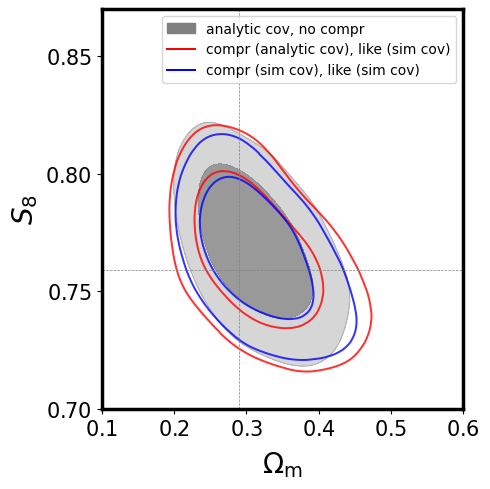

In [55]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = True
g.plot_2d([s_2pt, twpt_all_sims_y3cosmo, s_2pt_simsim_y3cosmo], 'om', 's8', filled=[True, False, False, False], \
    colors=['gray', 'red', 'blue'], alphas=[0.8, 0.8, 0.8, 0.8])
g.add_legend(['analytic cov, no compr', \
    'compr (analytic cov), like (sim cov)', \
    'compr (sim cov), like (sim cov)'],
    legend_loc='upper right', fontsize=10)
g.add_x_marker(0.29)
g.add_y_marker(0.759)
g.get_axes().set_xlim(0.1, 0.6)
g.get_axes().set_ylim(0.7, 0.87)
ax = g.get_axes()  # Get the main axes object
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
g.export('contour2d_test_2pt_moped_cov_choice_500simcov_1March2025.pdf')

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.plot_2d([twpt_all_sims, auto_all_sims, auto_334_344_all_sims, all_sims], 'om', 's8', filled=True, 
    colors=['gray','red', 'green', 'blue'], alphas=[0.8,0.8, 0.8,0.8], markers={'om': 0.26, 's8':0.782})
g.add_legend(['2PCF', 'joint (auto)', 'joint (auto+334+344)', 'joint (all)'], legend_loc='upper right')
#plt.savefig("../plots/all_500_sims_dv_results.png")
plt.show()

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([twpt_all_sims, auto_all_sims, auto_334_344_all_sims, all_sims], 'om', 's8', filled=True, 
    colors=['gray','red', 'green', 'blue'], alphas=[0.8,0.8, 0.8,0.8])
g.add_legend(['2PCF', \
    r'+$\langle M_{\rm ap}^3\rangle$ (auto)', 
    r'+$\langle M_{\rm ap}^3\rangle$ (auto+334+344)', 
    r'+$\langle M_{\rm ap}^3\rangle$ (all)'], legend_loc='upper right', fontsize=10)
g.add_x_marker(0.26)
g.add_y_marker(0.782)
g.get_axes().set_xlim(0.1, 0.6)
g.get_axes().set_ylim(0.7, 0.87)
g.export('../plots/contour2d_cosmogrid_dv_and_cov_19Sep24.pdf')

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([twpt_all_sims_update, auto_all_sims, auto_334_344_all_sims, all_sims], 'om', 's8', filled=True, 
    colors=['gray','red', 'green', 'blue'], alphas=[0.8,0.8, 0.8,0.8])
g.add_legend(['2PCF', \
    r'+$\langle M_{\rm ap}^3\rangle$ (auto)', 
    r'+$\langle M_{\rm ap}^3\rangle$ (auto+334+344)', 
    r'+$\langle M_{\rm ap}^3\rangle$ (all)'], legend_loc='upper right', fontsize=10)
g.add_x_marker(0.26)
g.add_y_marker(0.782)
g.get_axes().set_xlim(0.1, 0.6)
g.get_axes().set_ylim(0.7, 0.87)
#g.export('../plots/contour2d_cosmogrid_dv_and_cov_5Sep24.pdf')

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([twpt_all_sims, twpt_all_sims_update], 'om', 's8', filled=True, 
    colors=['green','red'], alphas=[0.8,0.8])
g.add_legend(['2PCF (analytic cov)','2PCF (updated)'], legend_loc='upper right', fontsize=10)
g.add_x_marker(0.26)
g.add_y_marker(0.782)
g.get_axes().set_xlim(0.1, 0.6)
g.get_axes().set_ylim(0.7, 0.87)
#g.export('../plots/contour2d_cosmogrid_dv_and_cov_5Sep24.pdf')

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([desy3_dm, desy3_baryon], 'om', 's8', filled=True, 
    colors=['green','red'], alphas=[0.8,0.8])
g.add_legend(['dm','baryon'], legend_loc='upper right', fontsize=10)
g.add_x_marker(0.26)
g.add_y_marker(0.782)
g.get_axes().set_xlim(0.1, 0.6)
g.get_axes().set_ylim(0.7, 0.87)
#g.export('../plots/contour2d_cosmogrid_dv_and_cov_5Sep24.pdf')

In [ ]:
# Define the parameters you're interested in
params = ['om', 's8', 'h0', 'cosmological_parameters--n_s', 'cosmological_parameters--omega_b', 'cosmological_parameters--mnu', 'w0']

for param in params:
    # Get quantiles for the parameter (68% confidence interval)
    v1 = desy3_baryon.confidence(param, 0.16, upper=False)
    v2 = desy3_baryon.confidence(param, 0.16, upper=True)
    
    # Compute the peak (mean)
    peak = desy3_baryon.getMeans()
    
    print(f"Parameter: {param}")
    print(f"Peak: {peak}")
    print(f"1-sigma Lower: {v1}")
    print(f"1-sigma Upper: {v2}")

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([twopoint_wCDM, all_sims_wCDM], 's8', 'w0', filled=True, 
    colors=['gray', 'red', 'blue', 'green'], alphas=[0.8, 0.8, 0.8])
g.add_legend([r'2PCF', r'+$\langle M_{\rm ap}^3\rangle$'], legend_loc='upper right')
g.add_x_marker(0.782)
g.add_y_marker(-1.0)
#plt.suptitle(r'$w$CDM', y=1.02, x = 0.59, fontsize=14)
plt.savefig('../plots/wCDM_contour2d_cosmogrid_dv_and_cov_25Sep24.pdf')

In [ ]:
import numpy as np

# Load the MCMC samples from your file
# Assuming your file is a space-separated text file with columns corresponding to parameters and log-posterior
data1 = np.loadtxt('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim1.txt')
data2 = np.loadtxt('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim2.txt')
data3 = np.loadtxt('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim3.txt')

data_all = np.loadtxt('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-2pt-map3-all.txt')
map3_data_all = np.loadtxt('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-map3-all.txt')
twpt_data_all = np.loadtxt('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-2pt-500simcov.txt')

log_posterior = twpt_data_all[:, -2]
parameters = twpt_data_all[:, :-2]

# Find the index of the sample with the highest log-posterior
best_fit_index = np.argmax(log_posterior)
best_fit_params = parameters[best_fit_index]

print("Best-fit parameters:")
for i, param_value in enumerate(best_fit_params):
    print(f"Parameter {i}: {param_value:.5f}")